# Multi-seed Multipath DLGN Experiments (5 seeds)

This notebook runs the multipath workflow from `scratch.ipynb` across 5 master seeds.

Per seed run modes:
- `two_phase_phase1`
- `two_phase_phase2_nozero`
- `two_phase_phase2_zeroed`
- `one_phase`

Design goals:
- Reduce checkpoint memory by using `snapshot_stride=200`.
- Keep the ability to draw scatter plots at any checkpoint epoch.
- Produce aggregate summaries across seeds and run modes.

In [1]:
import copy
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from layer_lenses.odt import generate_cob_odt_data
from layer_lenses.dlgn import DLGNSF
from layer_lenses.training import (
    TrainConfig,
    train_dlgn_sf,
    evaluate_dlgn_sf,
    effective_gating_weights_from_checkpoint,
    set_seed,
)

## Global settings (aligned with current scratch defaults)

This block keeps architecture and data scale consistent with your existing experiments, while changing checkpoint stride to 200 for memory convenience.

In [ ]:
# ---- Core settings ----
DIM = 100
DEPTH = 5
N_TRAIN = 80_000
HIDDEN_DIMS = [16, 16, 16, 16, 16]
BETA = 11.0

TOTAL_EPOCHS = 410
PHASE1_EPOCHS = 400
PHASE2_EPOCHS = TOTAL_EPOCHS - PHASE1_EPOCHS

SNAPSHOT_STRIDE = 2 # Be careful to not set this too small : each snapshot is a full model state, and hence memory intensive
# hierarchical emergence plots : keep snaphot stride and total epochs small to get  
# Phase2 is useless here, so phase1 can be almost equal to total epochs

# analysis of accuracy across run modes: keep snaphot stride and total epochs large. Phase1 epochs is half of total epochs

CHECKPOINT_EPOCHS_PHASE1 = tuple(range(0, PHASE1_EPOCHS + 1, SNAPSHOT_STRIDE))
CHECKPOINT_EPOCHS_PHASE2 = tuple(range(0, PHASE2_EPOCHS + 1, SNAPSHOT_STRIDE))
CHECKPOINT_EPOCHS_ONE = tuple(range(0, TOTAL_EPOCHS + 1, SNAPSHOT_STRIDE))

DEVICE = "cpu"
GATING_NORM_ZERO_THRESHOLD = 2.5

# num_seeds master seeds, so total snapshots will be num_seeds*total_epochs/snapshot_stride
MASTER_SEEDS = [5178, 6178, 7178, 8178, 9178, 10178, 11178, 12178, 13178, 14178]    

SEED_OFFSETS = {
    "data": 0,
    "init": 1000,
    "phase1_train": 2000,
    "phase2_train": 2001,
    "one_phase_train": 2002,
}

def derive_seed_bundle(master_seed: int) -> dict:
    return {
        "master_seed": master_seed,
        "data_seed": master_seed + SEED_OFFSETS["data"],
        "init_seed": master_seed + SEED_OFFSETS["init"],
        "phase1_train_seed": master_seed + SEED_OFFSETS["phase1_train"],
        "phase2_train_seed": master_seed + SEED_OFFSETS["phase2_train"],
        "one_phase_train_seed": master_seed + SEED_OFFSETS["one_phase_train"],
    }

def make_model() -> DLGNSF:
    return DLGNSF(
        input_dim=DIM,
        hidden_dims=HIDDEN_DIMS,
        beta=BETA,
        bias=False,
        value_input_mode="ones",
        gating_weight_scale=1.0,
        value_weight_scale=1.0,
    )

## Helpers

These functions run all branches for one seed, and provide utility functions for gating-vector scatter plots from checkpoint snapshots.

In [111]:
def stack_gating_numpy(gating_weights: list[torch.Tensor]) -> np.ndarray:
    return np.concatenate([w.detach().cpu().numpy() for w in gating_weights], axis=0)


def neuron_alignment_stats(gating_vecs: np.ndarray, odt_normals: np.ndarray):
    norms = np.linalg.norm(gating_vecs, axis=1)
    gv_norm = np.linalg.norm(gating_vecs, axis=1, keepdims=True) + 1e-12
    odt_norm = np.linalg.norm(odt_normals, axis=1, keepdims=True).T + 1e-12
    cos = (gating_vecs @ odt_normals.T) / (gv_norm * odt_norm)
    maxcos = np.max(np.abs(cos), axis=1)
    closest = np.argmax(np.abs(cos), axis=1)
    return norms, maxcos, closest


def regenerate_split_from_seed(data_seed: int):
    x, y, _, _ = generate_cob_odt_data(
        num_data=2 * N_TRAIN,
        dim=DIM,
        depth=DEPTH,
        seed=data_seed,
        threshold=0.0,
    )
    return x[:N_TRAIN], y[:N_TRAIN], x[N_TRAIN:], y[N_TRAIN:]


def run_single_seed_with_checkpoints(master_seed: int) -> dict:
    seeds = derive_seed_bundle(master_seed)

    x, y, tree, meta = generate_cob_odt_data(
        num_data=2 * N_TRAIN,
        dim=DIM,
        depth=DEPTH,
        seed=seeds["data_seed"],
        threshold=0.0,
    )
    x_train, y_train = x[:N_TRAIN], y[:N_TRAIN]
    x_eval, y_eval = x[N_TRAIN:], y[N_TRAIN:]

    # Phase 1 (shared base)
    set_seed(seeds["init_seed"])
    model_two_phase = make_model()

    train_cfg_phase1 = TrainConfig(
        epochs=PHASE1_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase1_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE1,
        show_progress=False,
        weight_decay_gating=2e-4,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_two_phase_phase1 = train_dlgn_sf(
        model=model_two_phase,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase1,
    )
    phase1_model_base = out_two_phase_phase1["model"]

    # Phase 2 (no zeroing)
    train_cfg_phase2 = TrainConfig(
        epochs=PHASE2_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase2_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE2,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_two_phase_phase2_nozero = train_dlgn_sf(
        model=copy.deepcopy(phase1_model_base),
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase2,
    )

    # Phase 2 (zeroed + frozen)
    phase2_model_zeroed = copy.deepcopy(phase1_model_base)
    with torch.no_grad():
        for layer in phase2_model_zeroed.gating_layers:
            row_norms = layer.weight.norm(dim=1)
            keep_mask = row_norms >= GATING_NORM_ZERO_THRESHOLD
            layer.weight[~keep_mask, :] = 0.0

    train_cfg_phase2_zeroed = TrainConfig(
        epochs=PHASE2_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["phase2_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_PHASE2,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
        freeze_zero_gating_rows=True,
    )
    out_two_phase_phase2_zeroed = train_dlgn_sf(
        model=phase2_model_zeroed,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_phase2_zeroed,
    )

    # One-phase baseline
    set_seed(seeds["init_seed"])
    model_one_phase = make_model()

    train_cfg_one_phase = TrainConfig(
        epochs=TOTAL_EPOCHS,
        lr=1e-3,
        batch_size=N_TRAIN // 500,
        seed=seeds["one_phase_train_seed"],
        device=DEVICE,
        snapshot_epochs=CHECKPOINT_EPOCHS_ONE,
        show_progress=False,
        weight_decay_gating=0.0,
        weight_decay_value=0.0,
        lr_scheduler="cosine",
        lr_scheduler_eta_min_ratio=0.2,
    )
    out_one_phase = train_dlgn_sf(
        model=model_one_phase,
        x_train=x_train,
        y_train=y_train,
        config=train_cfg_one_phase,
    )

    return {
        "seeds": seeds,
        "tree": tree,
        "meta": meta,
        "runs": {
            "two_phase_phase1": {"out": out_two_phase_phase1, "train_cfg": train_cfg_phase1},
            "two_phase_phase2_nozero": {"out": out_two_phase_phase2_nozero, "train_cfg": train_cfg_phase2},
            "two_phase_phase2_zeroed": {"out": out_two_phase_phase2_zeroed, "train_cfg": train_cfg_phase2_zeroed},
            "one_phase": {"out": out_one_phase, "train_cfg": train_cfg_one_phase},
        },
    }


def plot_scatter_for_checkpoint(all_results: Dict[int, dict], master_seed: int, run_mode: str, epoch: int, figsize=(7, 5)):
    seed_result = all_results[master_seed]
    run_block = seed_result["runs"][run_mode]
    out = run_block["out"]
    checkpoint_snapshots = out["checkpoint_snapshots"]

    if epoch not in checkpoint_snapshots:
        available = sorted(checkpoint_snapshots.keys())
        raise ValueError(f"epoch={epoch} not available. Available checkpoints: {available}")

    model_template = out["model"]
    gw = effective_gating_weights_from_checkpoint(model_template, checkpoint_snapshots[epoch])
    gw_stack = stack_gating_numpy(gw)

    odt_normals = seed_result["tree"].w_list
    norms, maxcos, closest = neuron_alignment_stats(gw_stack, odt_normals)
    closest_level = np.floor(np.log2(closest + 1)).astype(int)
    num_levels = int(np.floor(np.log2(odt_normals.shape[0] + 1)))

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap("viridis", num_levels)
    sc = ax.scatter(
        norms,
        maxcos,
        c=closest_level,
        s=50,
        alpha=0.90,
        cmap=cmap,
        vmin=-0.5,
        vmax=num_levels - 0.5,
    )
    ax.set_xlabel("||gating vector||", fontsize=16)
    ax.set_ylabel("max |cosine| to ODT normals", fontsize=16)
    ax.set_title(f"Seed={master_seed} | Mode={run_mode} | Epoch={epoch}", fontsize=14)
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(plt.matplotlib.ticker.MaxNLocator(nbins=3))
    ax.tick_params(axis="both", labelsize=14)
    # cax = ax.inset_axes([0.86, 0.12, 0.035, 0.36])
    # cbar = fig.colorbar(sc, cax=cax, ticks=np.arange(num_levels))
    # cbar.set_label("Closest ODT node level", fontsize=10)
    # cbar.ax.tick_params(labelsize=8)
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
    return fig

## First ODT alignment hit epochs

Find, for each seed/run mode/ODT internal node, the first checkpoint epoch where at least one gating neuron aligns above a chosen cosine threshold.

In [12]:
def first_odt_alignment_hit_epochs(
    all_results: Dict[int, dict],
    *,
    threshold: float = 0.8,
    norm_threshold: float = 0.0,
    run_modes: str | list[str] | tuple[str, ...] | None = None,
    use_abs: bool = True,
) -> pd.DataFrame:
    """Return first checkpoint where a gating neuron passes norm and alignment thresholds.

    By default this thresholds ``abs(cosine)`` to match the scatter plots above.
    Set ``use_abs=False`` to require signed positive cosine > threshold.
    """
    rows = []

    for master_seed, seed_result in all_results.items():
        odt_normals = seed_result["tree"].w_list
        odt_norms = np.linalg.norm(odt_normals, axis=1, keepdims=True).T + 1e-12
        if run_modes is None:
            selected_run_modes = seed_result["runs"].keys()
        elif isinstance(run_modes, str):
            selected_run_modes = (run_modes,)
        else:
            selected_run_modes = run_modes

        for run_mode in selected_run_modes:
            run_block = seed_result["runs"][run_mode]
            out = run_block["out"]
            model_template = out["model"]
            checkpoint_snapshots = out["checkpoint_snapshots"]
            epochs_sorted = sorted(checkpoint_snapshots.keys())

            hits_by_node = {
                odt_node_id: None for odt_node_id in range(odt_normals.shape[0])
            }

            for epoch in epochs_sorted:
                gw = effective_gating_weights_from_checkpoint(
                    model_template,
                    checkpoint_snapshots[epoch],
                )
                layer_widths = [w.shape[0] for w in gw]
                layer_offsets = np.cumsum([0, *layer_widths[:-1]])
                gw_stack = stack_gating_numpy(gw)
                gw_norms = np.linalg.norm(gw_stack, axis=1, keepdims=True) + 1e-12
                gw_norm_values = gw_norms[:, 0]
                norm_pass = gw_norm_values > norm_threshold
                cosine = (gw_stack @ odt_normals.T) / (gw_norms * odt_norms)
                score = np.abs(cosine) if use_abs else cosine

                for odt_node_id in range(odt_normals.shape[0]):
                    if hits_by_node[odt_node_id] is not None:
                        continue

                    neuron_scores = score[:, odt_node_id]
                    hit_mask = norm_pass & (neuron_scores > threshold)
                    if not np.any(hit_mask):
                        continue

                    candidate_neuron_ids = np.flatnonzero(hit_mask)
                    best_candidate_idx = int(np.argmax(neuron_scores[candidate_neuron_ids]))
                    best_neuron_id = int(candidate_neuron_ids[best_candidate_idx])

                    layer_id = int(np.searchsorted(layer_offsets, best_neuron_id, side="right") - 1)
                    layer_neuron_id = int(best_neuron_id - layer_offsets[layer_id])
                    hits_by_node[odt_node_id] = {
                        "master_seed": master_seed,
                        "run_mode": run_mode,
                        "odt_node_id": odt_node_id,
                        "first_epoch": int(epoch),
                        "global_neuron_id": best_neuron_id,
                        "layer": layer_id,
                        "layer_neuron_id": layer_neuron_id,
                        "gating_norm": float(gw_norm_values[best_neuron_id]),
                        "cosine": float(cosine[best_neuron_id, odt_node_id]),
                        "abs_cosine": float(abs(cosine[best_neuron_id, odt_node_id])),
                        "cosine_threshold": float(threshold),
                        "norm_threshold": float(norm_threshold),
                        "used_abs": bool(use_abs),
                    }

                if all(hit is not None for hit in hits_by_node.values()):
                    break

            for odt_node_id, hit in hits_by_node.items():
                if hit is None:
                    rows.append(
                        {
                            "master_seed": master_seed,
                            "run_mode": run_mode,
                            "odt_node_id": odt_node_id,
                            "first_epoch": np.nan,
                            "global_neuron_id": np.nan,
                            "layer": np.nan,
                            "layer_neuron_id": np.nan,
                            "gating_norm": np.nan,
                            "cosine": np.nan,
                            "abs_cosine": np.nan,
                            "cosine_threshold": float(threshold),
                            "norm_threshold": float(norm_threshold),
                            "used_abs": bool(use_abs),
                        }
                    )
                else:
                    rows.append(hit)

    return pd.DataFrame(rows).sort_values(
        ["master_seed", "run_mode", "odt_node_id"],
        ignore_index=True,
    )

## Run checkpoint-rich experiments for all 5 seeds

This stores checkpoint snapshots needed for scatter plots.

Note: this can take time and memory depending on your environment.

In [5]:
all_results: Dict[int, dict] = {}

for ms in MASTER_SEEDS:
    print(f"Running master seed: {ms}")
    all_results[ms] = run_single_seed_with_checkpoints(ms)

print("Done.")

Running master seed: 5178
Running master seed: 6178
Running master seed: 7178
Running master seed: 8178
Running master seed: 9178
Running master seed: 10178
Running master seed: 11178
Running master seed: 12178
Running master seed: 13178
Running master seed: 14178
Done.


In [ ]:
# # saving results to pickle file
# from pathlib import Path
# import gzip
# import pickle
# from datetime import datetime

# save_dir = Path("results/notebook_cache")
# save_dir.mkdir(parents=True, exist_ok=True)

# tag = datetime.now().strftime("%Y%m%dT%H%M%S")
# save_path = save_dir / f"all_results_{tag}.pkl.gz"

# with gzip.open(save_path, "wb") as f:
#     pickle.dump(all_results, f, protocol=pickle.HIGHEST_PROTOCOL)

# print(f"Saved: {save_path}")

Saved: results/notebook_cache/all_results_20260507T080213.pkl.gz


In [118]:
# Loading from pickle file.
from pathlib import Path
import gzip
import pickle

# replace with your chosen file
# load_path = Path("results/notebook_cache/all_results_20260429T072807.pkl.gz") #the april 29 file has longer runs but lesser checkpoints
load_path = Path("results/notebook_cache/all_results_20260507T080213.pkl.gz") #the may 7 file has shorter runs but more checkpoints
with gzip.open(load_path, "rb") as f:
    all_results = pickle.load(f)

print(f"Loaded keys (master seeds): {list(all_results.keys())}")

Loaded keys (master seeds): [5178, 6178, 7178, 8178, 9178, 10178, 11178, 12178, 13178, 14178]


In [119]:
from itables import show
selected_results = {ms: all_results[ms] for ms in MASTER_SEEDS if ms==5178}
odt_alignment_hit_epochs = first_odt_alignment_hit_epochs(
    selected_results,
    threshold=0.8,
    norm_threshold=3.,
    use_abs=True,
    run_modes=["two_phase_phase1"],
)

show(
    odt_alignment_hit_epochs,
    scrollY="500px",
    scrollX=True,
    search=True,
    paging=True,
    pageLength=32,
)

Loading ITables v2.7.3 from the internet... (need help?)


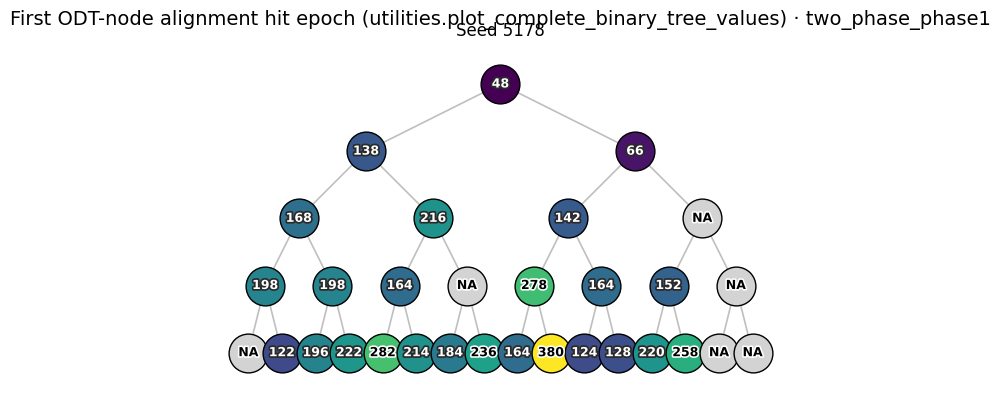

In [124]:
from layer_lenses.utilities import plot_complete_binary_tree_values

# Example: one seed + run mode → vector in breadth-order ODT internal node ids (same layout as plot_phase1_odt_hit_epoch_trees)
_run_mode_utility = "two_phase_phase1"
_seed_utility = sorted(odt_alignment_hit_epochs["master_seed"].unique())[0]

_df_u = odt_alignment_hit_epochs[
    (odt_alignment_hit_epochs["run_mode"] == _run_mode_utility)
    & (odt_alignment_hit_epochs["master_seed"] == _seed_utility)
]
_n_int = int(_df_u["odt_node_id"].max()) + 1
_hit_epoch_vec = (
    _df_u.set_index("odt_node_id")["first_epoch"].reindex(range(_n_int)).to_numpy(dtype=float)
)

fig_utility_tree, ax_utility_tree = plot_complete_binary_tree_values(
    _hit_epoch_vec,
    title=f"Seed {_seed_utility}",
    suptitle=f"First ODT-node alignment hit epoch (utilities.plot_complete_binary_tree_values) · {_run_mode_utility}",
)


## Phase-1 ODT hit-epoch trees

Visualize `two_phase_phase1` hit epochs on the complete ODT internal-node tree, one subplot per seed.

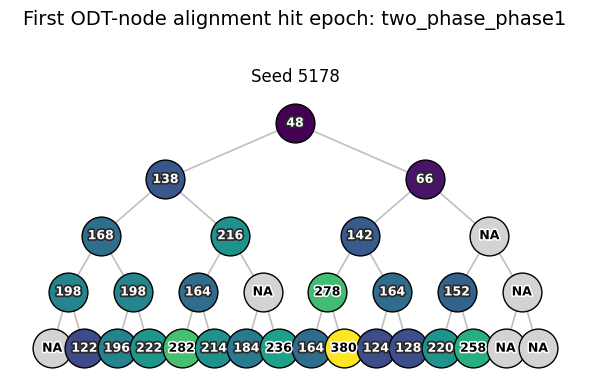

In [122]:
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


def _epoch_tree_label_style(facecolor):
    """Pick contrasting text color and outline for labels on colored scatter markers."""
    r, g, b = mcolors.to_rgba(facecolor)[:3]
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    if luminance < 0.5:
        return "white", [pe.withStroke(linewidth=2.5, foreground="#2a2a2a")]
    return "black", [pe.withStroke(linewidth=2.25, foreground="white")]


def _complete_binary_internal_node_positions(num_internal_nodes: int) -> dict[int, tuple[float, float]]:
    depth_float = np.log2(num_internal_nodes + 1)
    depth = int(depth_float)
    if (2**depth) - 1 != num_internal_nodes:
        raise ValueError(
            "num_internal_nodes must describe a complete binary tree, "
            f"got {num_internal_nodes}."
        )

    positions = {}
    for node_id in range(num_internal_nodes):
        level = int(np.floor(np.log2(node_id + 1)))
        level_start = (2**level) - 1
        index_in_level = node_id - level_start
        x = (index_in_level + 0.5) / (2**level)
        y = -level
        positions[node_id] = (x, y)
    return positions


def plot_phase1_odt_hit_epoch_trees(
    hit_epochs: pd.DataFrame,
    *,
    run_mode: str = "two_phase_phase1",
    ncols: int = 2,
    figsize_per_panel: tuple[float, float] = (6.0, 3.8),
):
    """Plot one ODT internal-node tree per seed, labeled by first hit epoch."""
    phase_df = hit_epochs[hit_epochs["run_mode"] == run_mode].copy()
    if phase_df.empty:
        raise ValueError(f"No rows found for run_mode={run_mode!r}.")

    seeds = sorted(phase_df["master_seed"].unique().tolist())
    num_internal_nodes = int(phase_df["odt_node_id"].max()) + 1
    positions = _complete_binary_internal_node_positions(num_internal_nodes)

    finite_epochs = phase_df["first_epoch"].dropna()
    cmap = plt.get_cmap("viridis")
    norm = None
    if not finite_epochs.empty:
        vmin = float(finite_epochs.min())
        vmax = float(finite_epochs.max())
        if vmin == vmax:
            vmax = vmin + 1.0
        norm = plt.Normalize(vmin=vmin, vmax=vmax)

    ncols = min(ncols, len(seeds))
    nrows = int(np.ceil(len(seeds) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    for ax, master_seed in zip(axes_flat, seeds):
        seed_df = phase_df[phase_df["master_seed"] == master_seed]
        epoch_by_node = seed_df.set_index("odt_node_id")["first_epoch"].to_dict()

        for parent_id in range(num_internal_nodes):
            for child_id in (2 * parent_id + 1, 2 * parent_id + 2):
                if child_id >= num_internal_nodes:
                    continue
                x0, y0 = positions[parent_id]
                x1, y1 = positions[child_id]
                ax.plot([x0, x1], [y0, y1], color="0.75", linewidth=1.2, zorder=1)

        for node_id, (x, y) in positions.items():
            epoch = epoch_by_node.get(node_id, np.nan)
            if pd.isna(epoch) or norm is None:
                facecolor = "lightgray"
                epoch_label = "NA"
            else:
                facecolor = cmap(norm(float(epoch)))
                epoch_label = str(int(epoch))

            ax.scatter(
                [x],
                [y],
                s=780,
                color=facecolor,
                edgecolor="black",
                linewidth=1.0,
                zorder=2,
            )
            text_color, path_eff = _epoch_tree_label_style(facecolor)
            ax.text(
                x,
                y,
                epoch_label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color,
                path_effects=path_eff,
                zorder=3,
            )

        ax.set_title(f"Seed {master_seed}")
        ax.set_axis_off()
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-(int(np.log2(num_internal_nodes + 1)) - 1) - 0.6, 0.6)

    for ax in axes_flat[len(seeds):]:
        ax.set_axis_off()


    fig.suptitle(f"First ODT-node alignment hit epoch: {run_mode}", y=1.02, fontsize=14)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_phase1_odt_hit_epoch_trees(
    odt_alignment_hit_epochs,
    run_mode="two_phase_phase1",
    ncols=2,
)

In [123]:
fig.savefig("results/DLGN_phase1_odt_hit_epoch_trees_5178.pdf")

## Scatter plots: any seed, mode, checkpoint

Pick any seed from `MASTER_SEEDS`, run mode, and available checkpoint epoch.

Run modes:
- `two_phase_phase1`
- `two_phase_phase2_nozero`
- `two_phase_phase2_zeroed`
- `one_phase`

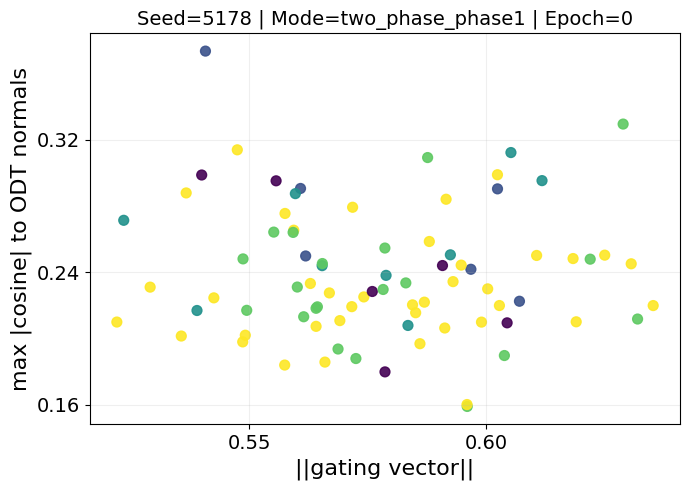

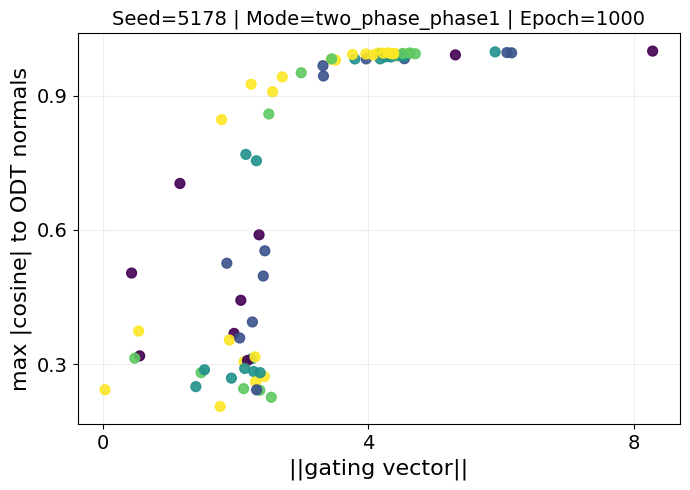

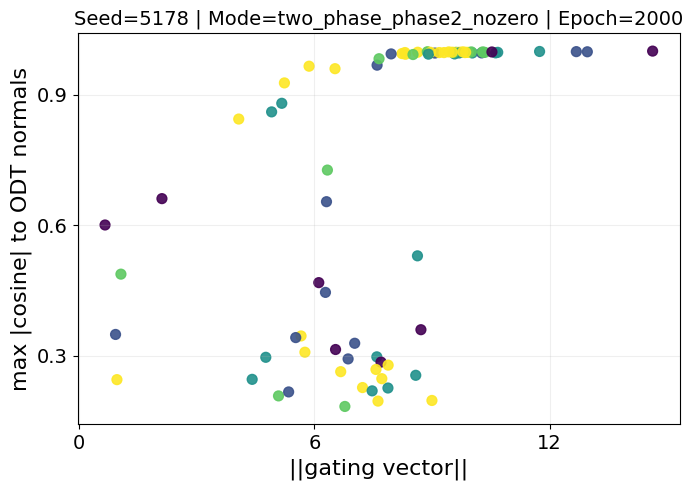

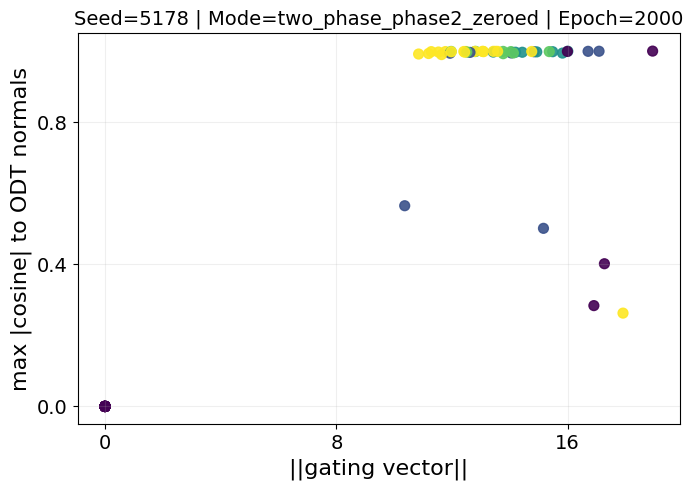

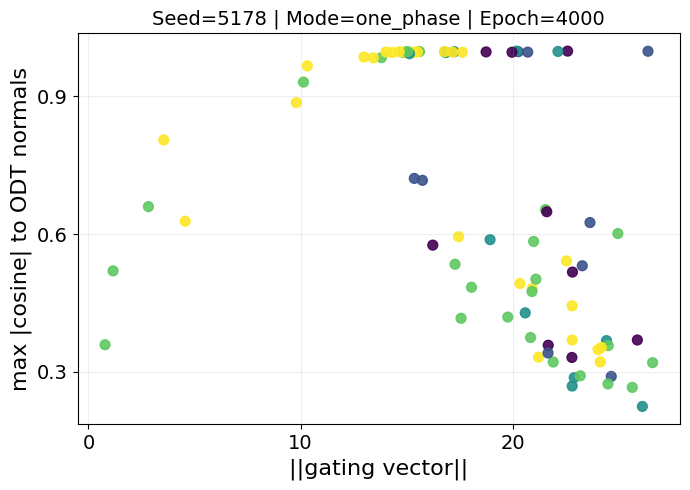

In [113]:
# Example calls
mseed = MASTER_SEEDS[0]
fig = plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase1", epoch=0)
fig = plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase1", epoch=1000)
# fig.savefig("results/DLGN_2phase_phase1_scatter.pdf")
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase2_nozero", epoch=2000)
plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="two_phase_phase2_zeroed", epoch=2000)
fig = plot_scatter_for_checkpoint(all_results, master_seed=mseed, run_mode="one_phase", epoch=4000)
fig.savefig("results/DLGN_one_phase_scatter.pdf")

## Start/end metrics from checkpoints for all seeds and modes

This computes (per seed, per mode):
- training log loss at start and end checkpoint
- test error (zero-one loss) at start and end checkpoint

Then it aggregates mean/std across seeds.

In [116]:
rows = []

for master_seed, seed_result in all_results.items():
    data_seed = seed_result["seeds"]["data_seed"]
    x_train, y_train, x_eval, y_eval = regenerate_split_from_seed(data_seed)

    for run_mode, run_block in seed_result["runs"].items():
        out = run_block["out"]
        ckpts = out["checkpoint_snapshots"]
        epochs_sorted = sorted(ckpts.keys())
        e0, eN = epochs_sorted[0], epochs_sorted[-1]

        eval_model = copy.deepcopy(out["model"]).to(DEVICE)

        for label, ep in [("start", e0), ("end", eN)]:
            eval_model.load_state_dict(ckpts[ep])

            m_tr = evaluate_dlgn_sf(model=eval_model, x_eval=x_train, y_eval=y_train, device=DEVICE)
            m_te = evaluate_dlgn_sf(model=eval_model, x_eval=x_eval, y_eval=y_eval, device=DEVICE)

            rows.append(
                {
                    "master_seed": master_seed,
                    "run_mode": run_mode,
                    "timepoint": label,
                    "epoch": ep,
                    "train_log_loss": m_tr["log_loss"],
                    "test_error": m_te["zero_one_loss"],
                }
            )

stats_df = pd.DataFrame(rows)
per_seed_table = stats_df.sort_values(["run_mode", "master_seed", "timepoint"]).reset_index(drop=True)

agg_table = (
    stats_df.groupby(["run_mode", "timepoint"], as_index=False)
    .agg(
        n=("master_seed", "count"),
        train_log_loss_mean=("train_log_loss", "mean"),
        train_log_loss_std=("train_log_loss", "std"),
        test_error_mean=("test_error", "mean"),
        test_error_std=("test_error", "std"),
    )
    .sort_values(["run_mode", "timepoint"])
    .reset_index(drop=True)
)

show(
    per_seed_table,
    scrollY="500px",
    scrollX=True,
    search=True,
    paging=True,
    pageLength=20,
)
display(agg_table)

Loading ITables v2.7.3 from the internet... (need help?)


,run_mode,timepoint,n,train_log_loss_mean,train_log_loss_std,test_error_mean,test_error_std
0,one_phase,end,10,6.222436e-02,8.086939e-02,0.178069,0.049171
1,one_phase,start,10,6.931486e-01,8.851873e-06,0.498841,0.004501
2,two_phase_phase1,end,10,3.590302e-02,3.214889e-02,0.131472,0.007495
3,two_phase_phase1,start,10,6.931486e-01,8.851873e-06,0.498841,0.004501
4,two_phase_phase2_nozero,end,10,5.226799e-07,8.594527e-07,0.089091,0.007365
5,two_phase_phase2_nozero,start,10,3.590302e-02,3.214889e-02,0.131472,0.007495
6,two_phase_phase2_zeroed,end,10,2.234711e-02,3.421653e-02,0.060220,0.007981
7,two_phase_phase2_zeroed,start,10,3.057269e+00,1.264491e+00,0.171900,0.028026
